In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
import re


import warnings
warnings.filterwarnings('ignore')
import string

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Loading dataset

In [4]:
df= pd.read_csv("email.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df.shape

(5573, 2)

In [7]:
df.isnull().sum()

,0
Category,0
Message,0


In [8]:
df.columns

Index(['Category', 'Message'], dtype='object')

<Axes: xlabel='count', ylabel='Category'>

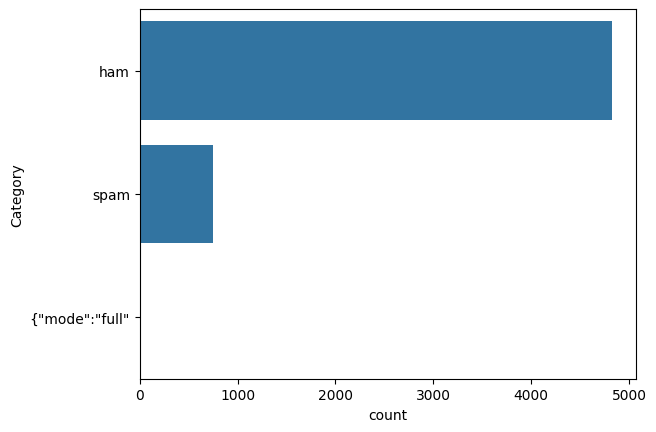

In [9]:
cat_count=df['Category'].value_counts
sns.countplot(df['Category'])

In [10]:
df.describe()

,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


Label encoding

In [11]:
encoder=LabelEncoder()
df['Category']=encoder.fit_transform(df['Category'])
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
message=df['Message']
message.head()

,Message
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
message=message.str.lower()
message.head()

,Message
0,"go until jurong point, crazy.. available only ..."
1,ok lar... joking wif u oni...
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor... u c already then say...
4,"nah i don't think he goes to usf, he lives aro..."


In [14]:
from numpy._core.defchararray import translate
translator= str.maketrans('','',string.punctuation)
message= message.apply(lambda x:x.translate(translator))
message.head()

,Message
0,go until jurong point crazy available only in ...
1,ok lar joking wif u oni
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor u c already then say
4,nah i dont think he goes to usf he lives aroun...


In [15]:
stop_words= set(stopwords.words('english'))
lemmatizer= WordNetLemmatizer()

def preprocess_text(txt):
  txt= str(txt).lower()
  words= txt.split()

  words= [word for word in words if word not in stop_words]

  words=[lemmatizer.lemmatize(word) for word in words]

  return ' '.join(words)

In [16]:
message= message.apply(preprocess_text)
message.head()

,Message
0,go jurong point crazy available bugis n great ...
1,ok lar joking wif u oni
2,free entry 2 wkly comp win fa cup final tkts 2...
3,u dun say early hor u c already say
4,nah dont think go usf life around though


In [17]:
tok= Tokenizer(num_words=9000)
tok.fit_on_texts(message)

In [18]:
word_index= tok.word_index
print(len(word_index))
list(word_index.items())[:10]

9000


[('u', 1),
 ('call', 2),
 ('2', 3),
 ('im', 4),
 ('get', 5),
 ('ur', 6),
 ('go', 7),
 ('4', 8),
 ('dont', 9),
 ('ok', 10)]

In [19]:
sequence= tok.texts_to_sequences(message)


In [20]:
message[0]

'go jurong point crazy available bugis n great world la e buffet cine got amore wat'

In [21]:
sequence[0]

[7, 4043, 273, 594, 560, 1106, 40, 61, 251, 1107, 88, 2659, 1108, 17, 4044, 73]

In [22]:
len(sequence)

5573

spliting X and y

In [23]:
X=[seq for seq in sequence]
y=df['Category']

In [24]:
y

,Category
0,0
1,0
2,1
3,0
4,0
...,...
5568,0
5569,0
5570,0
5571,0


In [25]:
len(X)

5573

In [26]:
max_len= max(len(x) for x in X)
max_len

80

In [27]:
X_padded= pad_sequences(X, maxlen=max_len,padding='pre')
X_padded

array([[   0,    0,    0, ...,   17, 4044,   73],
       [   0,    0,    0, ...,  351,    1, 1664],
       [   0,    0,    0, ..., 2661,  297, 2662],
       ...,
       [   0,    0,    0, ...,  850,    1,   12],
       [   0,    0,    0, ..., 2355,  383,  172],
       [   0,    0,    0, ...,    0,    0,    0]], dtype=int32)

In [28]:
y=np.array(y)
y

array([0, 0, 1, ..., 0, 0, 2])

In [29]:
X_padded.shape

(5573, 80)

In [30]:
y.shape

(5573,)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)

In [32]:
embedding= 50
rnn_units= 128
lstm_model=Sequential()
lstm_model.add(Embedding(input_dim=9000, output_dim=embedding, input_length=max_len))
lstm_model.add(LSTM(units=rnn_units, return_sequences=True))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(3, activation='softmax'))

In [33]:
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [34]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Redefine the LSTM model with return_sequences=False
lstm_model= Sequential()
lstm_model.add(Embedding(input_dim=9000,output_dim=embedding,input_length=max_len))
lstm_model.add(LSTM(units=rnn_units,return_sequences=False)) # FIX: Changed to False
lstm_model.add(Dense(units=3,activation='softmax')) # FIX: Changed units to 3 and activation to softmax

# Recompile the model
lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']) # FIX: Changed loss to sparse_categorical_crossentropy

epochs=100
batch_size= 128
history_lstm=lstm_model.fit(X_train,y_train,epochs=epochs,batch_size=batch_size,validation_split=0.1)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8517 - loss: 0.4389 - val_accuracy: 0.9103 - val_loss: 0.2500
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9626 - loss: 0.1473 - val_accuracy: 0.9596 - val_loss: 0.1264
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9833 - loss: 0.0576 - val_accuracy: 0.9753 - val_loss: 0.0818
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9920 - loss: 0.0332 - val_accuracy: 0.9664 - val_loss: 0.1120
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9940 - loss: 0.0256 - val_accuracy: 0.9776 - val_loss: 0.0844
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9958 - loss: 0.0187 - val_accuracy: 0.9619 - val_loss: 0.1266
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9975 - loss: 0.0131 - val_accuracy: 0.9686 - val_loss: 0.1162
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9980 - loss: 0.0100 - val_accuracy: 0.

In [47]:
pred_prob = lstm_model.predict(X_test,verbose=0)
predicted_class_index = np.argmax(pred_prob, axis=1)
for i in range(5):
  print(f"Actual: {y_test[i]}, Predicted: {predicted_class_index[i]}")

Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0


In [48]:
index_to_word={}
for word,index in word_index.items():
  index_to_word[index]=word

In [49]:
def perdictor(model,tok,text,max_len, label_encoder):
  text= text.lower()
  seq= tok.texts_to_sequences([text])[0]
  seq= pad_sequences([seq],maxlen=max_len,padding='pre')

  pred_prob = model.predict(seq,verbose=0)
  predicted_class_index = np.argmax(pred_prob, axis=1)[0] # Get the index of the class with highest probability

  # Use the label_encoder to get the original category name
  predicted_category = label_encoder.inverse_transform([predicted_class_index])[0]
  return predicted_category

In [50]:
seed_text='Invest just 0.5 BTC and receive 1 BTC back within 24 hours. Guaranteed returns. Limited-time offer. Send your Bitcoin now!'
prediction= perdictor(lstm_model,tok,seed_text,max_len, encoder)
print(prediction)

spam
